### Import Library

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("ecommerce-sales-clean.csv")

Mengubah tipe data dari data menjadi tipe data yang sesuai.

In [4]:
df["Order ID"] = df["Order ID"].astype('string')
df["Product"] = df["Product"].astype('category')
df["Quantity Ordered"] = df["Quantity Ordered"].astype(int)
df["Price Each"] = df["Price Each"].astype(float)
df["Purchase Address"] = df["Purchase Address"].astype('string')   
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["City"] = df["City"].astype('category')
df["Postal Code"] = df["Postal Code"].astype('category')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3852 entries, 0 to 3851
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          3852 non-null   string        
 1   Product           3852 non-null   category      
 2   Quantity Ordered  3852 non-null   int32         
 3   Price Each        3852 non-null   float64       
 4   Order Date        3852 non-null   datetime64[ns]
 5   Purchase Address  3852 non-null   string        
 6   City              3852 non-null   category      
 7   Postal Code       3852 non-null   category      
dtypes: category(3), datetime64[ns](1), float64(1), int32(1), string(2)
memory usage: 148.3 KB


In [6]:
df.describe(include=[int, float])

,Quantity Ordered,Price Each
count,3852.000000,3852.000000
mean,1.139408,176.340903
std,0.458095,323.792960
min,1.000000,2.990000
25%,1.000000,11.950000
50%,1.000000,14.950000
75%,1.000000,150.000000
max,6.000000,1700.000000


In [7]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City,Postal Code
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,917 1st St,Dallas,TX 75001
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,682 Chestnut St,Boston,MA 02215
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,669 Spruce St,Los Angeles,CA 90001
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,669 Spruce St,Los Angeles,CA 90001
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,333 8th St,Los Angeles,CA 90001


### Melihat Bentuk Distribusi Kolom Price Each

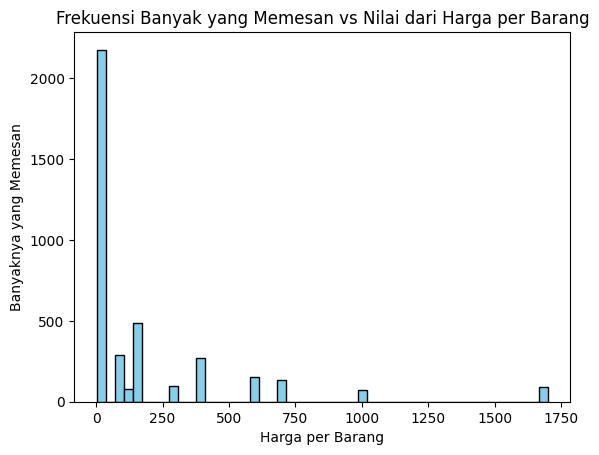

In [8]:
plt.hist(df["Price Each"], bins=50, color='skyblue', edgecolor='black')
plt.title('Frekuensi Banyak yang Memesan vs Nilai dari Harga per Barang')
plt.xlabel('Harga per Barang')
plt.ylabel('Banyaknya yang Memesan')
plt.show()

Bentuk distribusi tidak normal. Sehingga perlu menghitung IQR dari data Price, untuk mencari nilai yang dianggap outlier.

In [87]:
pd.DataFrame(df["Price Each"].describe())

,Price Each
count,3852.000000
mean,176.340903
std,323.792960
min,2.990000
25%,11.950000
50%,14.950000
75%,150.000000
max,1700.000000


Mencari IQR-nya terlebih dahulu : 
$$
IQR = Q_3 - Q_1
$$

Kemudian mencari batas bawah dan batas atas : 
$$
\text{Batas Bawah} = Q_1 - 1.5(IQR)
$$

$$
\text{Batas Atas} = Q_3 + 1.5(IQR)
$$

In [9]:
q3 = df["Price Each"].quantile(75/100)
q1 = df["Price Each"].quantile(25/100)
iqr = q3 - q1
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")

Q1: 11.95, Q3: 150.0, IQR: 138.05


In [10]:
batas_atas = df["Price Each"].quantile(75/100) + (1.5*iqr)
batas_atas

357.07500000000005

In [11]:
batas_bawah = df["Price Each"].quantile(25/100) - (1.5*iqr)
batas_bawah

-195.12500000000003

Tidak terdapat outlier di batas bawah.

In [12]:
len(df[df["Price Each"] < batas_bawah])

0

Terdapat 723 outlier di batas atas.

In [13]:
len(df[df["Price Each"] > batas_atas])

723

Nilai dari outliernya sendiri masih masuk akal, sehingga ini bukanlah salah ketik.

In [14]:
df["Price Each"].max()

1700.0

### Mencari Total Pemasukan pada Setiap Bulan

Membuat kolom Total pemasukan.

In [15]:
df["Total"] = df["Quantity Ordered"] * df["Price Each"]

In [16]:
total_pemasukan_per_bulan = pd.DataFrame(df.groupby(df["Order Date"].dt.to_period("M"))["Total"].sum()).reset_index()
total_pemasukan_per_bulan 

,Order Date,Total
0,2019-01,116555.27
1,2019-02,14990.81
2,2019-03,203967.78
3,2019-04,60794.85
4,2019-05,9176.06
5,2019-06,63833.86
6,2019-07,27918.16
7,2019-08,53010.02
8,2019-09,38925.19
9,2019-10,43798.09


In [17]:
total_pemasukan_per_bulan['Order Date'] = total_pemasukan_per_bulan['Order Date'].dt.strftime('%b')

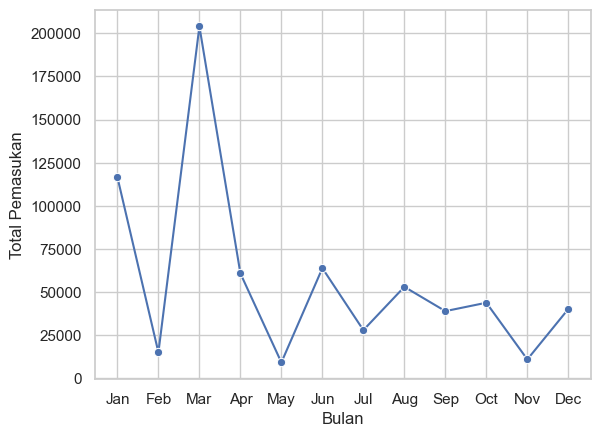

In [18]:
sns.set_theme(style='whitegrid')
sns.lineplot(
    data=total_pemasukan_per_bulan,
    x='Order Date',
    y='Total',
    marker='o'
)
plt.xlabel('Bulan')
plt.ylabel('Total Pemasukan')
plt.show()


### Mencari Produk Terlaris dan Produk dengan Pemasukan Terbesar

Produk dengan kuantitas pemesan terbanyak, beserta harganya.

In [19]:
kuantitas_terbanyak = df.groupby(["Product", "Price Each"])[["Quantity Ordered","Total"]].sum().sort_values(by="Quantity Ordered", ascending=False).head().reset_index()
kuantitas_terbanyak['Product'] = kuantitas_terbanyak['Product'].astype(str)
kuantitas_terbanyak

C:\Users\anggi\AppData\Local\Temp\ipykernel_24972\2271240438.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kuantitas_terbanyak = df.groupby(["Product", "Price Each"])[["Quantity Ordered","Total"]].sum().sort_values(by="Quantity Ordered", ascending=False).head().reset_index()


,Product,Price Each,Quantity Ordered,Total
0,AAA Batteries (4-pack),2.99,675,2018.25
1,AA Batteries (4-pack),3.84,593,2277.12
2,USB-C Charging Cable,11.95,513,6130.35
3,Lightning Charging Cable,14.95,486,7265.70
4,Wired Headphones,11.99,433,5191.67


Produk dengan pendapatan tertinggi beserta kuantitas pemesanannya.

In [20]:
pendapatan_tertinggi = df.groupby("Product").agg({"Total" : "sum", "Quantity Ordered" : "sum", "Price Each" : "median"}).sort_values(by="Total", ascending=False).head().reset_index()
pendapatan_tertinggi["Product"] = pendapatan_tertinggi["Product"].astype('string')
pendapatan_tertinggi

C:\Users\anggi\AppData\Local\Temp\ipykernel_24972\3547037036.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pendapatan_tertinggi = df.groupby("Product").agg({"Total" : "sum", "Quantity Ordered" : "sum", "Price Each" : "median"}).sort_values(by="Total", ascending=False).head().reset_index()


,Product,Total,Quantity Ordered,Price Each
0,Macbook Pro Laptop,156400.00,92,1700.00
1,iPhone,94500.00,135,700.00
2,Google Phone,77400.00,129,600.00
3,ThinkPad Laptop,71999.28,72,999.99
4,Apple Airpods Headphones,49350.00,329,150.00


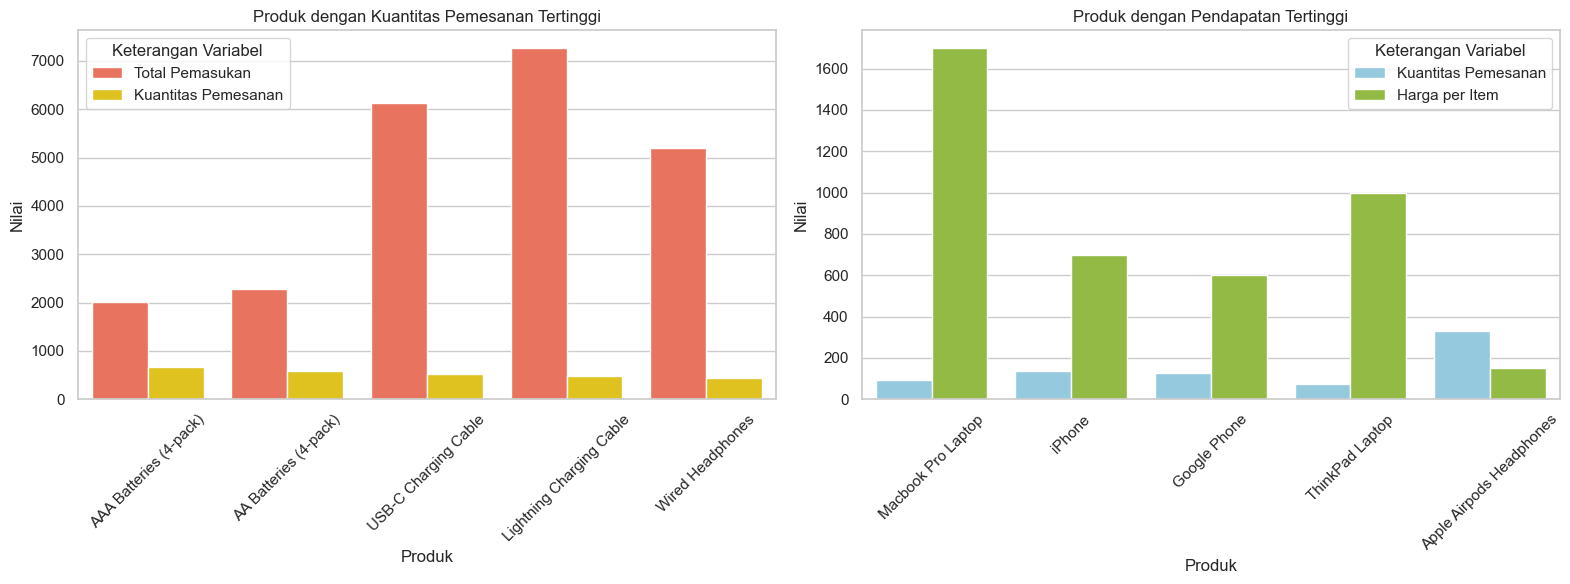

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_kiri = pd.melt(
    kuantitas_terbanyak, 
    id_vars=['Product'], 
    value_vars=['Total', 'Quantity Ordered'],  
    var_name='Keterangan Variabel', 
    value_name='value_name'
)

df_kanan = pd.melt(
    pendapatan_tertinggi, 
    id_vars=['Product'], 
    value_vars=['Quantity Ordered', 'Price Each'], 
    var_name='Keterangan Variabel', 
    value_name='value_name'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style='whitegrid')

# --- Grafik Kiri ---
sns.barplot(
    data=df_kiri, 
    x='Product', 
    y='value_name', 
    hue='Keterangan Variabel',
    palette=['tomato', 'gold'], 
    ax=axes[0]  
)

handles, labels = axes[0].get_legend_handles_labels()

axes[0].legend(handles=handles, labels=['Total Pemasukan', 'Kuantitas Pemesanan'], title='Keterangan Variabel')
axes[0].set_title('Produk dengan Kuantitas Pemesanan Tertinggi')
axes[0].set_xlabel('Produk')
axes[0].set_ylabel('Nilai')
axes[0].tick_params(axis='x', rotation=45) 

# --- Grafik Kanan ---
sns.barplot(
    data=df_kanan, 
    x='Product', 
    y='value_name', 
    hue='Keterangan Variabel', 
    palette=['skyblue', 'yellowgreen'],  
    ax=axes[1]  
)

handles, labels = axes[1].get_legend_handles_labels()

axes[1].legend(handles=handles, labels=['Kuantitas Pemesanan', 'Harga per Item'], title='Keterangan Variabel')
axes[1].set_title('Produk dengan Pendapatan Tertinggi')
axes[1].set_xlabel('Produk')
axes[1].set_ylabel('Nilai')
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()


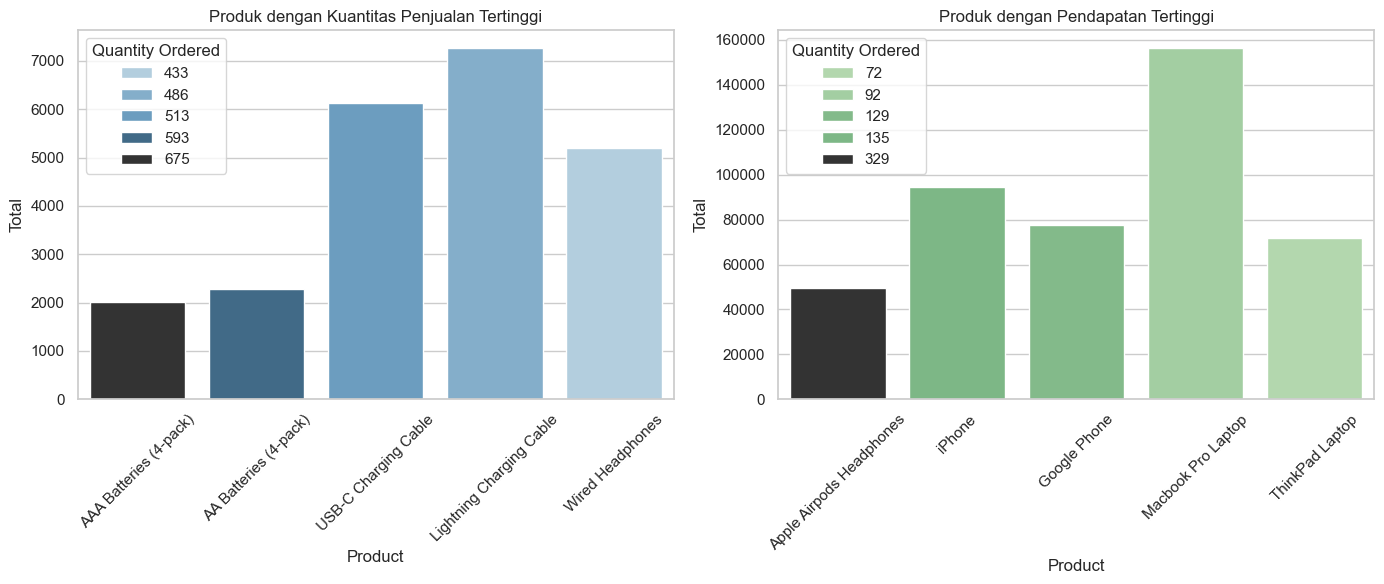

In [33]:
from matplotlib.ticker import FormatStrFormatter

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=kuantitas_terbanyak,
    x='Product',
    y='Total',
    palette='Blues_d',
    hue='Quantity Ordered',
    ax=axes[0]
)

axes[0].set_title('Produk dengan Kuantitas Penjualan Tertinggi')

sns.barplot(
    data=pendapatan_tertinggi.sort_values(
        by='Quantity Ordered',
        ascending=False
    ),
    x='Product',
    y='Total',
    palette='Greens_d',
    hue='Quantity Ordered',
    ax=axes[1]
)

axes[1].set_title('Produk dengan Pendapatan Tertinggi')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Produk yang paling laris terjual tiap bulan.

In [35]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City,Postal Code,Total
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,917 1st St,Dallas,TX 75001,23.90
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,682 Chestnut St,Boston,MA 02215,99.99
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,669 Spruce St,Los Angeles,CA 90001,600.00
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,669 Spruce St,Los Angeles,CA 90001,11.99
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,333 8th St,Los Angeles,CA 90001,11.99


In [61]:
produk_per_bulan = (df.groupby([df['Order Date'].dt.month, 'Product'])['Quantity Ordered'].sum().reset_index())
produk_terlaris_bulanan = (produk_per_bulan.loc[produk_per_bulan.groupby('Order Date')['Quantity Ordered'].idxmax()])
produk_terlaris_bulanan['Product'] = produk_terlaris_bulanan['Product'].astype('string')

print(produk_terlaris_bulanan)

     Order Date                 Product  Quantity Ordered
5             1  AAA Batteries (4-pack)               119
23            2   AA Batteries (4-pack)                20
43            3  AAA Batteries (4-pack)               196
62            4  AAA Batteries (4-pack)                62
93            5        Wired Headphones                12
99            6   AA Batteries (4-pack)                61
119           7  AAA Batteries (4-pack)                44
137           8   AA Batteries (4-pack)                70
157           9  AAA Batteries (4-pack)                33
176          10  AAA Batteries (4-pack)                60
205          11    USB-C Charging Cable                15
224          12    USB-C Charging Cable                48


C:\Users\anggi\AppData\Local\Temp\ipykernel_24972\3695528271.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  produk_per_bulan = (df.groupby([df['Order Date'].dt.month, 'Product'])['Quantity Ordered'].sum().reset_index())


In [72]:
data = pd.DataFrame(produk_terlaris_bulanan.groupby('Product')['Quantity Ordered'].sum().reset_index())


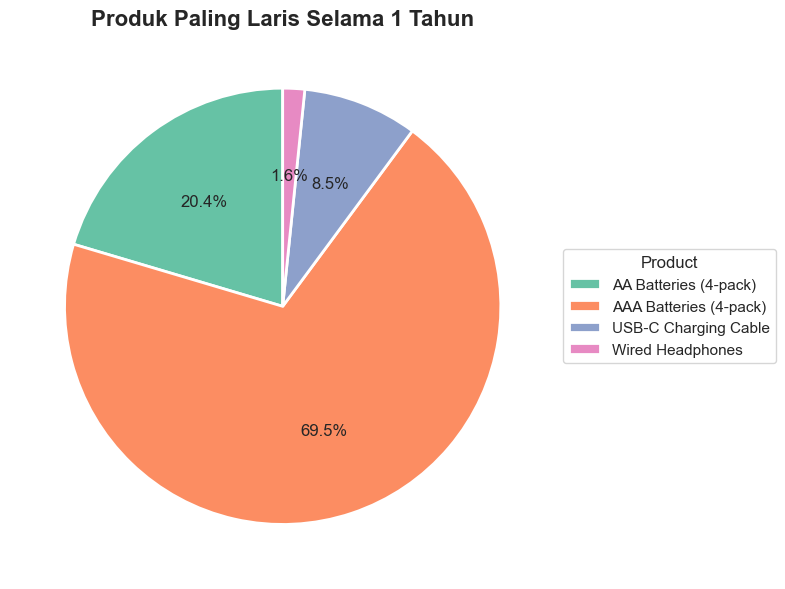

In [81]:
produk = data
colors = sns.color_palette('Set2', len(produk))

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    produk['Quantity Ordered'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.legend(
    wedges,
    produk['Product'],
    title='Product',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.title('Produk Paling Laris Selama 1 Tahun', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Mencari Probabilitas Terbelinya Suatu Produk

Seperti yang sudah kita ketahui produk dengan penghasilan terbesar adalah Macbook Pro Laptop, maka kita akan menghitung probabilitas dari pembelian produk Macbook pro laptop berdasarkan data bulan Januari.

In [98]:
penjualan_produk = pd.DataFrame(df[df['Order Date'].dt.year == 2019]['Product'].value_counts().reset_index())
total = penjualan_produk['count'].sum()
probabilitas_macbook_pro = (penjualan_produk[penjualan_produk['Product'] == 'Macbook Pro Laptop']['count'].values[0] / total)
print(penjualan_produk)
print(f"Total Penjualan Produk selama 2019 : {total}")
print(f"Probabilitas pembelian Macbook pro selama 2019 adalah : {probabilitas_macbook_pro*100:.2f}%")

                       Product  count
0         USB-C Charging Cable    462
1     Lightning Charging Cable    452
2       AAA Batteries (4-pack)    438
3        AA Batteries (4-pack)    428
4             Wired Headphones    398
5     Apple Airpods Headphones    323
6   Bose SoundSport Headphones    287
7             27in FHD Monitor    166
8                       iPhone    135
9                 Google Phone    129
10      27in 4K Gaming Monitor    115
11      34in Ultrawide Monitor    111
12               Flatscreen TV     96
13          Macbook Pro Laptop     92
14                20in Monitor     79
15             ThinkPad Laptop     72
16             Vareebadd Phone     45
17                    LG Dryer     14
18          LG Washing Machine     10
Total Penjualan Produk selama 2019 : 3852
Probabilitas pembelian Macbook pro selama 2019 adalah : 2.39%


Maka jika ingin mengetahui berapa probabilitas pembelian Macbook Pro Laptop sebanyak tepat 72 buah dari 3000 pembelian. Bisa  gunakan rumus probabilitas binomial berikut : 
$$
P(X=x) = \binom{n}{x} p^x q^{n-x}
$$

In [107]:
from scipy.stats import binom

n = 3000
x = 72
q = 1 - probabilitas_macbook_pro

probabilitas = binom.pmf(x, n, probabilitas_macbook_pro)

print(probabilitas)
print(f'{probabilitas * 100:.2f}%')

0.047493982509822806
4.75%


Dengan estimasi probabilitas pembelian Produk B sebesar 2,39%, probabilitas terjadinya tepat 72 pembelian Produk B dari 3000 pembelian adalah sekitar 4,75%.